In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend

In [2]:
# Carga el dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Numero de patrones en dataset de entrenamiento: 60000
Tamaño de imagenes en dataset de entrenamiento: (28, 28)


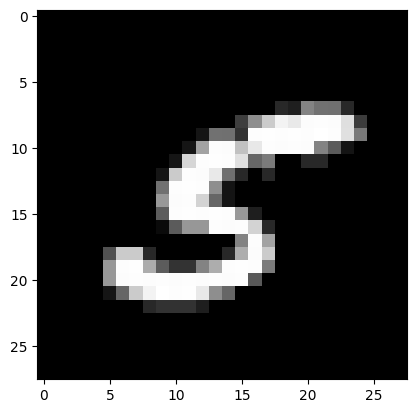

In [3]:
print("Numero de patrones en dataset de entrenamiento: {0}".format(x_train.shape[0]))
print("Tamaño de imagenes en dataset de entrenamiento: {0}".format(x_train.shape[1 :]))

# Muestra una imagen del dataset aleatoriamente
plt.imshow(x_train[np.random.randint(0, x_train.shape[0])],cmap='gray')

In [4]:
# Normalizamos dataset de entramiento y test
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Codifica el numero de canales, antes o despues depende del formato
if('channels_first' == backend.image_data_format()):
    x_train = x_train.reshape(x_train.shape[0], 1, x_train.shape[1], x_train.shape[2])
    x_test = x_test.reshape(x_test.shape[0], 1, x_test.shape[1], x_test.shape[2])
    input_shape = (1, x_test.shape[1], x_test.shape[2])
else:
    x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
    x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
    input_shape = (x_test.shape[1], x_test.shape[2], 1)

print("Dimensiones de la entrada : {0}".format(input_shape))

Dimensiones de la entrada : (28, 28, 1)


In [5]:
num_classes = 10

# Codificamos las etiquetas de entrenamiento y test a one-hot
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
def build_model():
# Create sequential model
    model = Sequential()

    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu',
                     input_shape=input_shape))
    
    model.add(Conv2D(64, kernel_size=(3, 3), 
                     activation='relu'))
    
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25)) # Drops 1/4 of input unit for regularization
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='adam',
                  metrics=['accuracy']) # Usamos accuracy para los problemas de clasificacion
    
    return model


In [7]:
# Crea la CNN
cnn = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Entrena el modelo
cnn.fit(x_train, y_train, batch_size=128,
        epochs=6, verbose=1,
        validation_data=(x_test, y_test))

Epoch 1/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 151s 319ms/step - accuracy: 0.8407 - loss: 0.5072 - val_accuracy: 0.9824 - val_loss: 0.0528
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 331ms/step - accuracy: 0.9741 - loss: 0.0869 - val_accuracy: 0.9875 - val_loss: 0.0383
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 318ms/step - accuracy: 0.9795 - loss: 0.0671 - val_accuracy: 0.9894 - val_loss: 0.0315
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 335ms/step - accuracy: 0.9846 - loss: 0.0506 - val_accuracy: 0.9885 - val_loss: 0.0349
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 317ms/step - accuracy: 0.9861 - loss: 0.0472 - val_accuracy: 0.9901 - val_loss: 0.0286
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 149s 317ms/step - accuracy: 0.9873 - loss: 0.0413 - val_accuracy: 0.9899 - val_loss: 0.0300


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


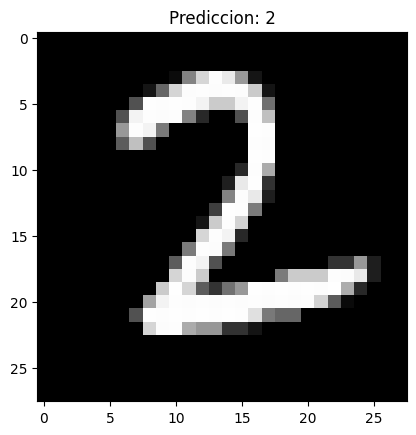

In [19]:
# Seleccionamos una imagen del dataset de prueba y hacemos una inferencia
pattern = x_test[np.random.randint(0, x_test.shape[0])].reshape(1, x_test.shape[1], x_test.shape[2], x_test.shape[3])
plt.imshow(pattern[0, :, :, 0], cmap='gray')
plt.title('Prediccion: ' + str(np.argmax(cnn.predict(pattern))))
plt.show()